# Crunching Game Stats

In [6]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [7]:
# Import csv file

df = pd.read_csv("game_stats.csv")

print(df.head())

   ID            Timestamp WinningTeam  RemainingVillagers  \
0   1  2025-08-29_18-21-26    werewolf                   0   
1   2  2025-08-29_18-22-05    villager                   1   
2   3  2025-08-29_18-22-14    werewolf                   0   
3   4  2025-08-29_18-28-44    villager                   1   
4   5  2025-08-29_18-29-22    villager                   3   

   RemainingWerewolves  
0                    1  
1                    0  
2                    1  
3                    0  
4                    0  


In [8]:
(df["WinningTeam"] == "villager").mean()

0.6248006379585327

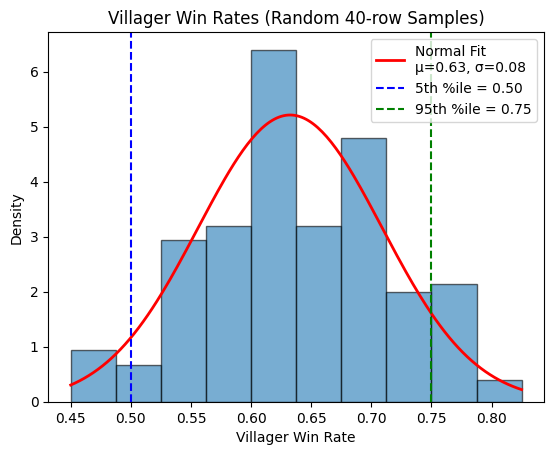

In [11]:
# Fitting normal curve to this

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Example: assume df is already loaded
# df = pd.read_csv("your_file.csv")

# Number of random samples
n_samples = 200

villager_win_rates = [
    (df.sample(n=40, replace=False)["WinningTeam"] == "villager").mean()
    for _ in range(n_samples)
]

# Convert to array
villager_win_rates = np.array(villager_win_rates)

# Fit normal distribution
mu, sigma = norm.fit(villager_win_rates)

# Compute percentiles
p5, p95 = np.percentile(villager_win_rates, [5, 95])

# Plot histogram
plt.hist(villager_win_rates, bins=10, density=True, alpha=0.6, edgecolor="black")

# Overlay fitted normal curve
x = np.linspace(min(villager_win_rates), max(villager_win_rates), 200)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label=f"Normal Fit\nμ={mu:.2f}, σ={sigma:.2f}")

# Mark percentiles
plt.axvline(p5, color='blue', linestyle='--', label=f"5th %ile = {p5:.2f}")
plt.axvline(p95, color='green', linestyle='--', label=f"95th %ile = {p95:.2f}")

# Labels
plt.xlabel("Villager Win Rate")
plt.ylabel("Density")
plt.title("Villager Win Rates (Random 40-row Samples)")
plt.legend()
plt.show()


# Making Heatmap

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

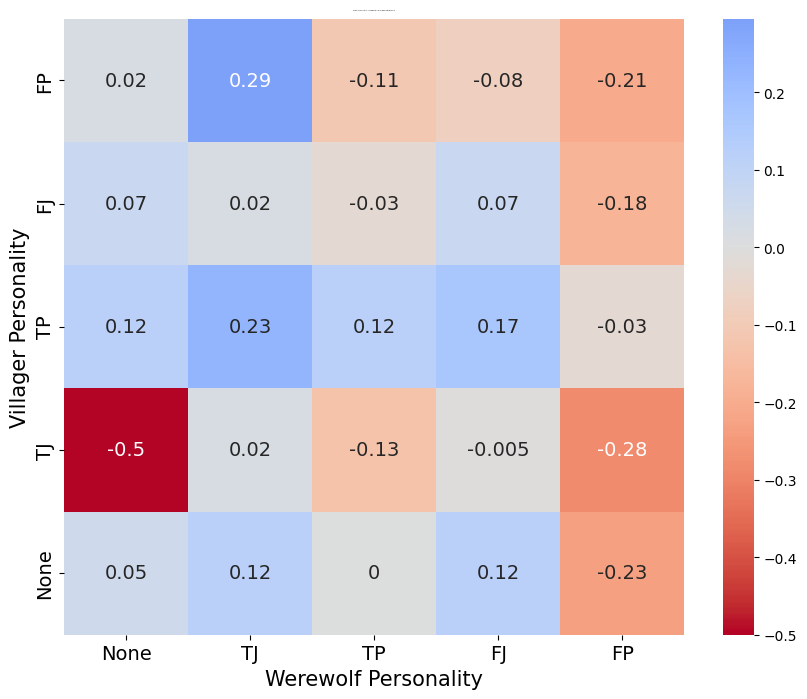

In [10]:
import pandas as pd

# Model basedon game-theoretic decision matrix

# Rows = Villager Settings
# Columns = Werewolf Settings

data_2d = np.array([
    [0, 0.07, -0.05, 0.07, -0.28],
    [-0.55, -0.03, -0.18, -0.055, -0.33],
    [0.07, 0.18, 0.07, 0.12, -0.08],
    [0.02, -0.03, -0.08, 0.02, -0.23],
    [-0.03, 0.245, -0.16, -0.13, -0.255]
])

data_2d = data_2d + 0.05

df = pd.DataFrame(
    data_2d,
    index=["None", "TJ", "TP", "FJ", "FP"],
    columns=["None", "TJ", "TP", "FJ", "FP"]
)


plt.figure(figsize=(10, 8)) 

sns.heatmap(
    df.iloc[::-1],
    annot=True,
    center=0,
    cmap="coolwarm_r",
    annot_kws={"size": 14}  # increase font size of cell numbers
)

plt.xlabel("Werewolf Personality", fontsize=15)   # x-axis label
plt.ylabel("Villager Personality", fontsize=15)    # y-axis label
plt.yticks(fontsize=14)  # row labels
plt.xticks(fontsize=14)  # column labels
plt.title("Effect of Personality Combinations on Villager Performance", fontsize=1)
plt.show()
